In [4]:
!pip install hdbscan kagglehub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [kagglehub]/3 [kagglesdk]

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [5]:
import os
# Работа с таблицами
import pandas as pd
import numpy as np

# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt

# Предобработка данных
from sklearn.preprocessing import StandardScaler, RobustScaler, QuantileTransformer
from sklearn.pipeline import Pipeline
from scipy import stats


# Уменьшение размерности
from sklearn.decomposition import PCA, FastICA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Алгоритмы кластеризации
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.ensemble import IsolationForest, \
                             RandomTreesEmbedding

from sklearn.model_selection import RandomizedSearchCV

from sklearn.mixture import GaussianMixture

# Метрики качества
from sklearn.metrics import accuracy_score, \
                            silhouette_score, \
                            davies_bouldin_score, \
                            silhouette_samples,\
                            calinski_harabasz_score

# Фиксация random_state
np.random.seed(42)

# Настройки графиков
sns.set(style='whitegrid')

plt.rcParams['figure.figsize'] = (10, 8)

# Загрузка и первичное исследование данных

In [9]:
df = pd.read_csv('Physical_Activity_Monitoring_unlabeled.csv')
print(df.shape)

df.head()

(534601, 53)


,timestamp,handTemperature,handAcc16_1,handAcc16_2,handAcc16_3,handAcc6_1,handAcc6_2,handAcc6_3,handGyro1,handGyro2,...,ankleGyro2,ankleGyro3,ankleMagne1,ankleMagne2,ankleMagne3,ankleOrientation1,ankleOrientation2,ankleOrientation3,ankleOrientation4,subject_id
0,252.75,34.8750,0.902847,7.45872,6.032490,1.006100,7.44575,6.303650,-0.021952,0.004114,...,-0.025606,0.030239,-14.5447,27.3336,-5.76620,0.206416,0.348212,0.763201,-0.503652,5
1,3652.45,29.7500,-4.069330,3.76168,8.279720,-5.972500,3.22273,6.908970,0.116054,-0.375968,...,-0.670163,1.786200,-32.8257,-15.7719,-1.31395,0.578332,-0.566734,0.405888,-0.423791,2
2,504.76,34.3750,-2.007540,-9.60180,0.773674,-1.803500,-9.58937,1.073680,0.020131,0.042189,...,-0.009741,-0.006579,-18.8171,16.3089,25.29280,0.139776,0.676586,0.393796,0.606316,8
3,2801.61,31.9375,-13.262200,5.85443,0.899334,-13.611500,5.91511,0.840377,1.715630,-0.050492,...,-0.163470,-3.495570,-26.7418,34.3566,21.32740,0.416303,0.783387,0.306464,0.345075,2
4,441.01,33.5000,-0.013940,8.66540,4.398210,0.144153,8.56816,4.822200,-0.006938,-0.007383,...,-0.028172,-0.003737,-17.7798,-3.9981,10.99500,0.171133,-0.748343,0.252988,-0.588807,6


In [10]:
def express_info(data, name='data', nans = True):
    '''Функция первичного исследования данных:
          - структура данных
          - пропуски
          - явные дубликаты
          - статистическое описание данных
       Аргументы:
          - data - датафрейм
          - name - название таблицы
          - nans флаг (True - результат пропущенных данных по столбцам)
    '''
    print(f'Размер данных ({name}):      {data.shape}')
    print(f'Количество явных дубликатов: {data.duplicated().sum()}')
    print(f'Наличие пропусков:           {data.isna().sum().sum()}')
    if nans:
        print(f'\nПропущенные данные:')
        #print(round(data.isna().mean()*100).sort_values(ascending=False).head(7), sep = '\n')
        print(data.isna().sum().sort_values(ascending=False).head(20), sep = '\n')        
    print(f'\nИнформация ({name}):')
    data.info()
    display(data.head(5))
    display(data.describe())
    print()

In [11]:
express_info(df,  nans = True)

Размер данных (data):      (534601, 53)
Количество явных дубликатов: 0
Наличие пропусков:           125732

Пропущенные данные:
handOrientation4     4041
handGyro2            4041
handOrientation3     4041
handOrientation2     4041
handOrientation1     4041
handMagne3           4041
handMagne1           4041
handGyro3            4041
handMagne2           4041
handGyro1            4041
handAcc6_3           4041
handAcc6_2           4041
handAcc6_1           4041
handAcc16_3          4041
handAcc16_2          4041
handAcc16_1          4041
handTemperature      4041
ankleOrientation4    2546
ankleAcc16_2         2546
ankleAcc16_3         2546
dtype: int64

Информация (data):
<class 'pandas.DataFrame'>
RangeIndex: 534601 entries, 0 to 534600
Data columns (total 53 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   timestamp          534601 non-null  float64
 1   handTemperature    530560 non-null  float64
 2   handAcc16_1       

,timestamp,handTemperature,handAcc16_1,handAcc16_2,handAcc16_3,handAcc6_1,handAcc6_2,handAcc6_3,handGyro1,handGyro2,...,ankleGyro2,ankleGyro3,ankleMagne1,ankleMagne2,ankleMagne3,ankleOrientation1,ankleOrientation2,ankleOrientation3,ankleOrientation4,subject_id
0,252.75,34.8750,0.902847,7.45872,6.032490,1.006100,7.44575,6.303650,-0.021952,0.004114,...,-0.025606,0.030239,-14.5447,27.3336,-5.76620,0.206416,0.348212,0.763201,-0.503652,5
1,3652.45,29.7500,-4.069330,3.76168,8.279720,-5.972500,3.22273,6.908970,0.116054,-0.375968,...,-0.670163,1.786200,-32.8257,-15.7719,-1.31395,0.578332,-0.566734,0.405888,-0.423791,2
2,504.76,34.3750,-2.007540,-9.60180,0.773674,-1.803500,-9.58937,1.073680,0.020131,0.042189,...,-0.009741,-0.006579,-18.8171,16.3089,25.29280,0.139776,0.676586,0.393796,0.606316,8
3,2801.61,31.9375,-13.262200,5.85443,0.899334,-13.611500,5.91511,0.840377,1.715630,-0.050492,...,-0.163470,-3.495570,-26.7418,34.3566,21.32740,0.416303,0.783387,0.306464,0.345075,2
4,441.01,33.5000,-0.013940,8.66540,4.398210,0.144153,8.56816,4.822200,-0.006938,-0.007383,...,-0.028172,-0.003737,-17.7798,-3.9981,10.99500,0.171133,-0.748343,0.252988,-0.588807,6


,timestamp,handTemperature,handAcc16_1,handAcc16_2,handAcc16_3,handAcc6_1,handAcc6_2,handAcc6_3,handGyro1,handGyro2,...,ankleGyro2,ankleGyro3,ankleMagne1,ankleMagne2,ankleMagne3,ankleOrientation1,ankleOrientation2,ankleOrientation3,ankleOrientation4,subject_id
count,534601.000000,530560.000000,530560.000000,530560.000000,530560.000000,530560.000000,530560.000000,530560.000000,530560.000000,530560.000000,...,532055.000000,532055.000000,532055.000000,532055.000000,532055.000000,532055.000000,532055.000000,532055.000000,532055.000000,534601.000000
mean,1593.538159,32.451221,-4.435286,3.241949,4.079375,-4.375896,3.218250,4.262513,-0.008852,0.028801,...,-0.031911,0.002304,-28.756284,2.115624,14.723345,0.360159,-0.091093,0.303517,-0.173845,4.558615
std,1243.906483,1.754847,7.062004,7.224031,3.831257,7.068961,6.864782,3.822053,1.160112,0.926832,...,0.618840,2.036102,19.303887,22.253170,17.907491,0.301254,0.559400,0.344271,0.466304,2.318076
min,37.660000,27.500000,-114.755000,-82.550900,-73.949700,-61.214700,-61.824200,-61.577100,-19.690500,-7.609010,...,-7.701040,-14.019600,-172.865000,-136.951000,-102.716000,0.000003,-0.954848,-0.876838,-0.997040,1.000000
25%,475.500000,31.312500,-9.076360,0.682775,1.588777,-8.981072,0.687587,1.780160,-0.153182,-0.083315,...,-0.049003,-0.221911,-39.689950,-10.960850,2.252230,0.145023,-0.676392,0.006839,-0.580040,2.000000
50%,827.610000,32.875000,-5.465610,3.089205,4.157125,-5.434845,3.127145,4.413625,-0.004439,0.004013,...,-0.004481,0.000354,-26.285600,-0.014372,16.599500,0.240996,0.000000,0.322698,-0.281681,5.000000
75%,2876.990000,33.812500,0.383679,5.559742,6.864212,0.424770,5.592180,7.148178,0.130310,0.094342,...,0.048972,0.032649,-14.549500,19.245900,25.947100,0.501671,0.410052,0.594198,0.252247,7.000000
max,4007.730000,35.250000,60.912600,155.532000,78.480100,34.159400,62.259800,60.843700,22.960000,11.862600,...,6.002540,14.482700,41.764800,92.867000,122.521000,1.000000,0.959538,0.920506,0.996105,8.000000


In [12]:
# Статистика по subject_id
print("\nУчастники эксперимента:")
print(df['subject_id'].value_counts().sort_index())


Участники эксперимента:
subject_id
1    69882
2    68740
3    50044
4    63740
5    76793
6    70240
7    62115
8    73047
Name: count, dtype: int64


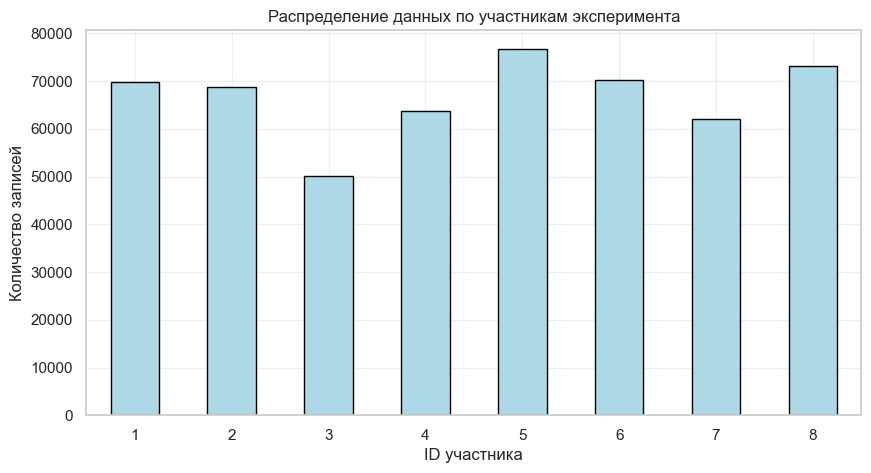

In [13]:
plt.figure(figsize=(10, 5))
df['subject_id'].value_counts().sort_index()\
                .plot(kind='bar', color='lightblue', edgecolor='black')
plt.xlabel('ID участника')
plt.ylabel('Количество записей')
plt.title('Распределение данных по участникам эксперимента')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3)
plt.show()

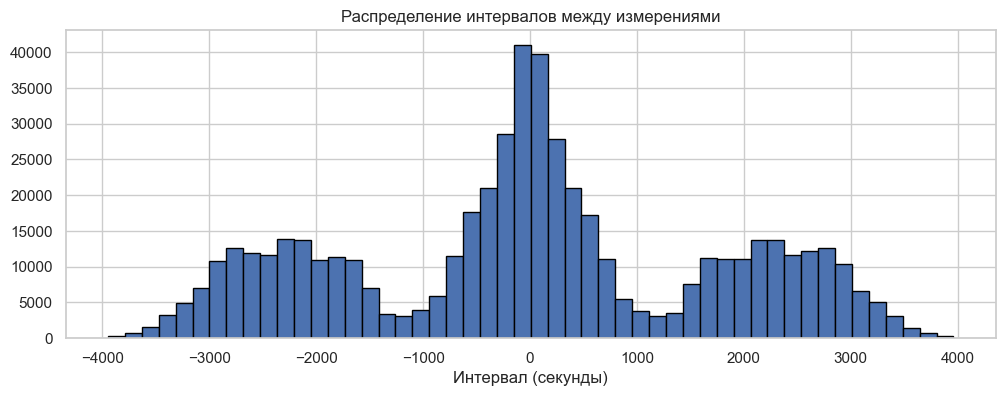

In [14]:
# Анализ временных меток
plt.figure(figsize=(12, 4))
plt.hist(df['timestamp'].diff().dropna(), bins=50, edgecolor='black')
plt.title('Распределение интервалов между измерениями')
plt.xlabel('Интервал (секунды)')
plt.show()

## Выводы:
- Размер данных (data):      (534601, 53)
- Количество явных дубликатов: 0
-  Пропуски в данных = 125732: много
    - Пропуски НЕ случайны: Все пропуски сконцентрированы в датчиках на руке (hand*)
    - У датчиков на груди и лодыжке пропусков значительно меньше или нет совсем, 
    скорее всего - человек мог снимать браслет с руки, но датчики на груди/лодыжке оставались.
    > Будем заполнять медианой по каждому `subject_id` отдельно (не по всем данным)

- Анализ временных меток `timestamp` показал:
    - Распределение нормальное.
    - Диапазон: от 37 до 4007 секунд (~1 час 7 минут)
    - Интервалы: есть отрицательные значения (ошибка синхронизации?)    
    - Разные субъекты имеют разные временные отрезки   
    - Это непрерывные временные ряды, а не независимые измерения!
- Дисбаланс участников (subject_id)
    - 1: 69,882 записей
    - 2: 68,740 записей
    - 3: 50,044 записей - меньше всех
    - 8: 73,047 записей - больше всех

## EDA

### Проверка на аномалии:

In [15]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Числовые признаки:", list(num_cols))

Числовые признаки: ['timestamp', 'handTemperature', 'handAcc16_1', 'handAcc16_2', 'handAcc16_3', 'handAcc6_1', 'handAcc6_2', 'handAcc6_3', 'handGyro1', 'handGyro2', 'handGyro3', 'handMagne1', 'handMagne2', 'handMagne3', 'handOrientation1', 'handOrientation2', 'handOrientation3', 'handOrientation4', 'chestTemperature', 'chestAcc16_1', 'chestAcc16_2', 'chestAcc16_3', 'chestAcc6_1', 'chestAcc6_2', 'chestAcc6_3', 'chestGyro1', 'chestGyro2', 'chestGyro3', 'chestMagne1', 'chestMagne2', 'chestMagne3', 'chestOrientation1', 'chestOrientation2', 'chestOrientation3', 'chestOrientation4', 'ankleTemperature', 'ankleAcc16_1', 'ankleAcc16_2', 'ankleAcc16_3', 'ankleAcc6_1', 'ankleAcc6_2', 'ankleAcc6_3', 'ankleGyro1', 'ankleGyro2', 'ankleGyro3', 'ankleMagne1', 'ankleMagne2', 'ankleMagne3', 'ankleOrientation1', 'ankleOrientation2', 'ankleOrientation3', 'ankleOrientation4', 'subject_id']


In [16]:
# Выбросы для всех колонок
def detect_outliers_iqr(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR))).sum()
    return outliers

# Получаем таблицу с количеством выбросов
outliers_count = df[num_cols].apply(detect_outliers_iqr).sort_values(ascending=False)
outliers_percent = (outliers_count / len(df)) * 100

outliers_summary = pd.DataFrame({
    'Колонка': outliers_count.index,
    'Кол-во выбросов': outliers_count.values,
    'Процент': outliers_percent.values
})

print("Топ-10 колонок с наибольшим количеством выбросов:")
print(outliers_summary.head(10))

Топ-10 колонок с наибольшим количеством выбросов:
        Колонка  Кол-во выбросов    Процент
0    ankleGyro1           198810  37.188483
1    ankleGyro3           196589  36.773033
2     handGyro3           183318  34.290620
3    ankleGyro2           182799  34.193539
4     handGyro2           167365  31.306526
5     handGyro1           155740  29.132007
6    chestGyro3           148673  27.810086
7    chestGyro2           137806  25.777355
8    chestGyro1           122141  22.847133
9  chestAcc16_3            85903  16.068619


### Обработка пропусков
#### по subject_id

In [17]:
print(f"Пропусков до обработки: {df.isnull().sum().sum()}")

# Удаляем timestamp из обработки (не заполняем пропуски в нем)
timestamp_col = 'timestamp'
subject_col = 'subject_id'
feature_cols = [col for col in df.columns if col not in [timestamp_col, subject_col]]

# Заполняем пропуски медианой по каждому субъекту
df_filled = df.copy()
for subject in df[subject_col].unique():
    mask = df[subject_col] == subject
    for col in feature_cols:
        median_val = df.loc[mask, col].median()
        df_filled.loc[mask, col] = df_filled.loc[mask, col].fillna(median_val)

print(f"Пропусков после обработки: {df_filled.isnull().sum().sum()}")

Пропусков до обработки: 125732
Пропусков после обработки: 0


Вывод:
- Видим массовые выбросы в гироскопах (30-37%). Скорее всего - это особенность физической активности(бег, прыжки, махи руками).
    > проблемные колонки: 'ankleGyro1', 'ankleGyro3', 'handGyro3', 'ankleGyro2', 'handGyro2', 'handGyro1', 'chestGyro3', 'chestGyro2', 'chestGyro1'
- это надо будет учесть при кластеризации
- строки и выбросы - не удаляем
- применяем RobustScaler в качестве стандартизации - сгладим выбросы
  > можно еще попробовать логарифмировть проблемные колонки (как 2 вариант набора данных).
- используем алгоритм, устойчивый к выбросам  - KMeans с нормализацией

## Формирование признаков

In [18]:
# Делаем subject_id мультииндексом с timestamp
df_filled = df_filled.set_index(['subject_id', 'timestamp'])
print(f"Индекс: {df_filled.index.names}")
print(f"Форма: {df_filled.shape}")

Индекс: ['subject_id', 'timestamp']
Форма: (534601, 51)


### Набор логарифмировнных данных

In [19]:
# Все колонки теперь признаки
X = df_filled

#problem_cols = ['ankleGyro1', 'ankleGyro3', 'handGyro3', 'ankleGyro2', 
#                'handGyro2', 'handGyro1', 'chestGyro3', 'chestGyro2', 'chestGyro1']
# Отделяем гироскопы (проблемные колонки)
gyro_cols = [col for col in X.columns if 'Gyro' in col]
other_cols = [col for col in X.columns if 'Gyro' not in col]
print(f"Гироскопов: {len(gyro_cols)}")
print(f"Остальных: {len(other_cols)}")
# Для гироскопов - логарифмическое преобразование для сжатия выбросов
#df_transformed = df.copy()
#for col in gyro_cols:
    # Добавляем константу, чтобы избежать log(0)
#    df_transformed[col] = np.log1p(np.abs(df[col])) * np.sign(df[col])
# 2 вариант логарифмическое преобразование
scaler_gyro = QuantileTransformer(output_distribution='normal')
X_gyro = scaler_gyro.fit_transform(X[gyro_cols])

# Для остальных - стандартное масштабирование
scaler_other = StandardScaler()
X_other = scaler_other.fit_transform(X[other_cols])

# Объединяем
X_scaled_log = np.hstack([X_gyro, X_other])

Гироскопов: 9
Остальных: 42


#### Набор данных стандартизированный RobustScaler()
RobustScaler - устойчив к выбросам

In [20]:
# Набор данных стандартизированный RobustScaler()
#X = df_filled
#df_scaled = df.copy()
print(f"\nПризнаки: {list(X.columns)}")

scaler = RobustScaler()  # Один скейлер для всех признаков
X_scaled = scaler.fit_transform(X)

print(f"\nФорма после масштабирования: {X_scaled.shape}")


Признаки: ['handTemperature', 'handAcc16_1', 'handAcc16_2', 'handAcc16_3', 'handAcc6_1', 'handAcc6_2', 'handAcc6_3', 'handGyro1', 'handGyro2', 'handGyro3', 'handMagne1', 'handMagne2', 'handMagne3', 'handOrientation1', 'handOrientation2', 'handOrientation3', 'handOrientation4', 'chestTemperature', 'chestAcc16_1', 'chestAcc16_2', 'chestAcc16_3', 'chestAcc6_1', 'chestAcc6_2', 'chestAcc6_3', 'chestGyro1', 'chestGyro2', 'chestGyro3', 'chestMagne1', 'chestMagne2', 'chestMagne3', 'chestOrientation1', 'chestOrientation2', 'chestOrientation3', 'chestOrientation4', 'ankleTemperature', 'ankleAcc16_1', 'ankleAcc16_2', 'ankleAcc16_3', 'ankleAcc6_1', 'ankleAcc6_2', 'ankleAcc6_3', 'ankleGyro1', 'ankleGyro2', 'ankleGyro3', 'ankleMagne1', 'ankleMagne2', 'ankleMagne3', 'ankleOrientation1', 'ankleOrientation2', 'ankleOrientation3', 'ankleOrientation4']

Форма после масштабирования: (534601, 51)


In [ ]:
# # Проверяем распределение
# plt.figure(figsize=(12, 4))
# plt.subplot(1, 2, 1)
# plt.hist(df['handGyro1'], bins=50, alpha=0.7)
# plt.title('До масштабирования')
# plt.subplot(1, 2, 2)
# plt.hist(df_scaled['handGyro1'], bins=50, alpha=0.7)
# plt.title('После RobustScaler')
# plt.show()

### Кластеризация
#### k-means

In [21]:
def lokot_method(X, name = None):
    wcss = []
    K_values = range(1, 15)
    
    for k in K_values:
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(X)
        wcss.append(kmeans.inertia_)  # inertia_ -- сумма квадратов расстояний точек до центроидов
    
    # Строим график
    plt.plot(K_values, wcss, marker='o', linestyle='-')
    plt.xlabel("Число кластеров (K)")
    plt.ylabel("WCSS")
    plt.title(f"Метод локтя для выбора K ({name})")
    plt.show()

##### Проверяем разные наборы данных

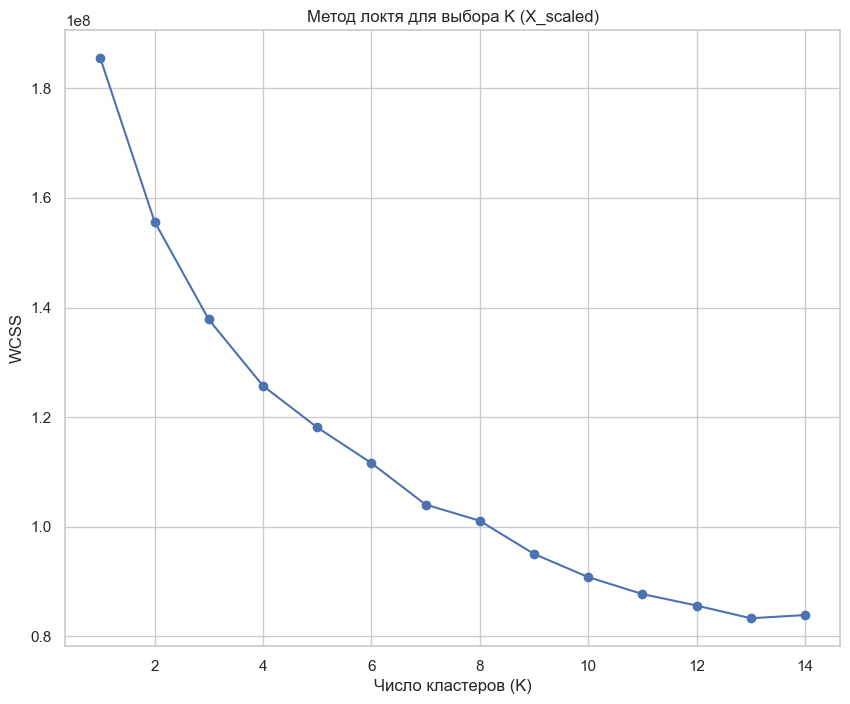

In [22]:
# Чистые данные
#lokot_method(X, 'X')
# Нормализованные данные RobustScaler
lokot_method(X_scaled, 'X_scaled')
# Нормализованные данные log+Standartscaler
#lokot_method(X_scaled_log, 'X_scaled_log')

In [23]:
def siluet_method(X, sample_size= 30000, kvalues_list=[2, 3, 4, 5, 6], name="X"):
    sample_size = sample_size
    np.random.seed(42)
    if hasattr(X, 'iloc'):  # Если DataFrame
        sample_indices = np.random.choice(len(X), sample_size, replace=False)
        X_sample = X.iloc[sample_indices].values
    else:  # Если numpy array
        sample_indices = np.random.choice(len(X), sample_size, replace=False)
        X_sample = X[sample_indices] # используем .iloc для DataFrame

    print(f'\nТестируем набор данных: {name}')
    k_values = kvalues_list
    for k in k_values:
        print(f"Тестируем k={k}")
        kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=5000, n_init=10)
        labels = kmeans.fit_predict(X_sample)
        score = silhouette_score(X_sample, labels)
        print(f"K={k}: Silhouette={score:.4f}")


In [24]:
%%time
siluet_method(X_scaled, 10000, [2, 3, 5, 8, 9, 10, 11, 12, 13, 14], 'X_scaled')
#siluet_method(X, 30000, [2, 3, 4, 5, 6], 'X')
#siluet_method(X_scaled_log, 30000, [2, 3, 4, 5, 6], 'X_scaled_log')


Тестируем набор данных: X_scaled
Тестируем k=2
K=2: Silhouette=0.4322
Тестируем k=3
K=3: Silhouette=0.4841
Тестируем k=5
K=5: Silhouette=0.0014
Тестируем k=8
K=8: Silhouette=0.4010
Тестируем k=9
K=9: Silhouette=0.0982
Тестируем k=10
K=10: Silhouette=0.1096
Тестируем k=11
K=11: Silhouette=0.3749
Тестируем k=12
K=12: Silhouette=0.0938
Тестируем k=13
K=13: Silhouette=0.1258
Тестируем k=14
K=14: Silhouette=0.1203
CPU times: user 13.7 s, sys: 19.8 s, total: 33.6 s
Wall time: 5.41 s


In [25]:
# берем выборку
sample_size = 30000  # можно уменьшить до 15000 для скорости
np.random.seed(42)
sample_indices = np.random.choice(len(X_scaled), sample_size, replace=False)
X_sample = X_scaled[sample_indices]


Статистика для K=2:
  Общий силуэт: 0.534
  Кластер 0: mean=0.047, std=0.139, size=2,400
  Кластер 1: mean=0.577, std=0.118, size=27,600

Статистика для K=3:
  Общий силуэт: 0.449
  Кластер 0: mean=0.044, std=0.135, size=2,139
  Кластер 1: mean=0.554, std=0.125, size=24,685
  Кластер 2: mean=-0.087, std=0.130, size=3,176

Статистика для K=5:
  Общий силуэт: 0.399
  Кластер 0: mean=0.045, std=0.140, size=943
  Кластер 1: mean=-0.049, std=0.146, size=1,553
  Кластер 2: mean=0.545, std=0.112, size=22,353
  Кластер 3: mean=-0.085, std=0.118, size=3,229
  Кластер 4: mean=0.060, std=0.138, size=1,922

Статистика для K=8:
  Общий силуэт: 0.376
  Кластер 0: mean=0.006, std=0.156, size=901
  Кластер 1: mean=0.235, std=0.149, size=920
  Кластер 2: mean=0.034, std=0.117, size=2,564
  Кластер 3: mean=0.497, std=0.108, size=21,814
  Кластер 4: mean=0.195, std=0.159, size=406
  Кластер 5: mean=0.071, std=0.146, size=1,138
  Кластер 6: mean=-0.037, std=0.150, size=1,380
  Кластер 7: mean=0.029, std=

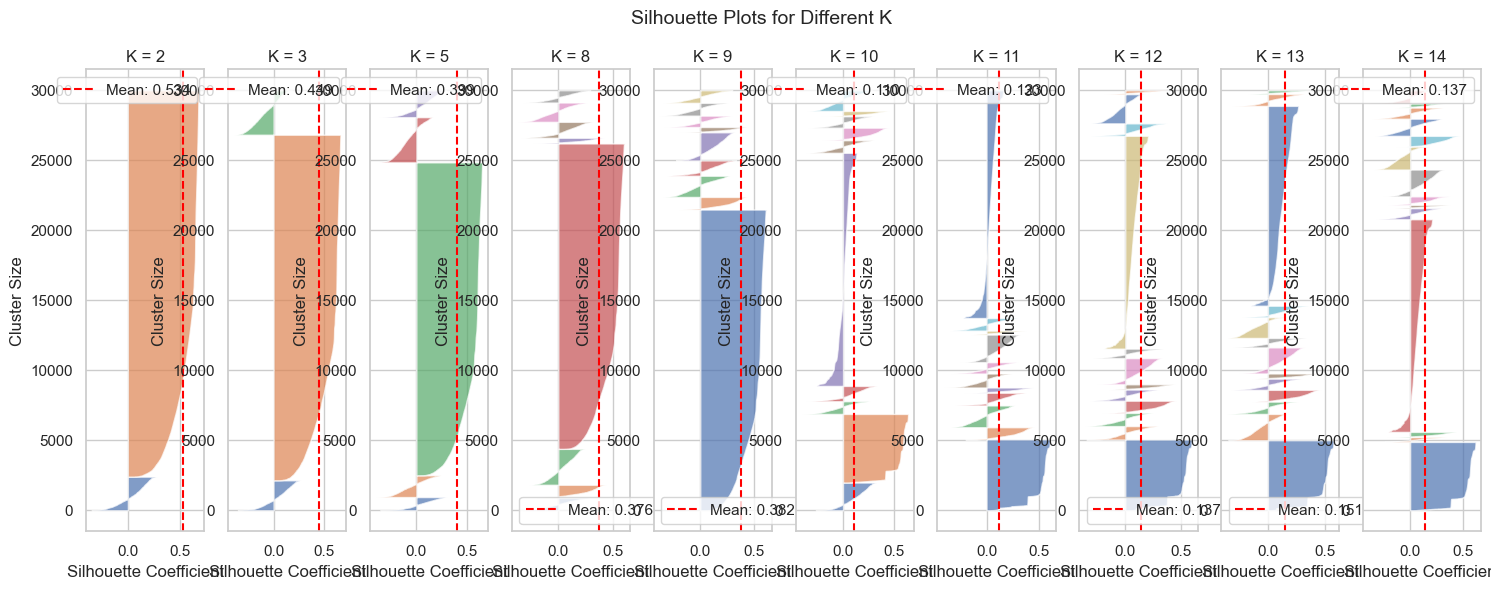

In [26]:
# Функция для построения силуэтных графиков (без изменений)
def plot_silhouette(X, cluster_counts):
    fig, axes = plt.subplots(1, len(cluster_counts), figsize=(18, 6))
    for idx, K in enumerate(cluster_counts):
        kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(X)
        # Вычисляем силуэтные коэффициенты
        silhouette_vals = silhouette_samples(X, cluster_labels)
        # Средний силуэтный коэффициент
        avg_score = silhouette_score(X, cluster_labels)

        y_lower, y_upper = 0, 0
        axes[idx].set_title(f"K = {K}")
        for i in range(K):
            cluster_silhouette_vals = silhouette_vals[cluster_labels == i]
            cluster_silhouette_vals.sort()

            y_upper += len(cluster_silhouette_vals)
            axes[idx].fill_betweenx(
                np.arange(y_lower, y_upper),
                0,
                cluster_silhouette_vals,
                alpha=0.7
            )
            y_lower = y_upper

        # Статистика
        print(f"\nСтатистика для K={K}:")
        print(f"  Общий силуэт: {avg_score:.3f}")
        for i in range(K):
            print(f"  Кластер {i}: mean={silhouette_vals[cluster_labels==i].mean():.3f}, "
                      f"std={silhouette_vals[cluster_labels==i].std():.3f}, "
                      f"size={sum(cluster_labels==i):,}")

        # Средний силуэтный коэффициент
        #avg_score = silhouette_score(X, cluster_labels)
        axes[idx].axvline(avg_score, linestyle="--", color="red", label=f"Mean: {avg_score:.3f}")
        axes[idx].legend()
        axes[idx].set_xlabel("Silhouette Coefficient")
        axes[idx].set_ylabel("Cluster Size")

    plt.suptitle("Silhouette Plots for Different K", fontsize=14)
    plt.show()


# берем выборку
sample_size = 30000  # можно уменьшить до 15000 для скорости
np.random.seed(42)
sample_indices = np.random.choice(len(X_scaled), sample_size, replace=False)
X_sample = X_scaled[sample_indices]

# Вызываем функцию для K= 2, 3 на выборке
plot_silhouette(X_sample, cluster_counts=[2, 3, 5, 8, 9, 10, 11, 12, 13, 14])

Значения нестабильны - скачут, лучшее значение у 2 кластера, но тут может быть  более сложная структура. Проверяем значения с помощью иерархической кластеризации.

#### Иерархическая кластеризация
- AgglomerativeClustering

In [27]:
# Для визуализации
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print('Размер после PCA:')
print(X_pca.shape)


Размер после PCA:
(534601, 2)


#### Построим Дендограмму

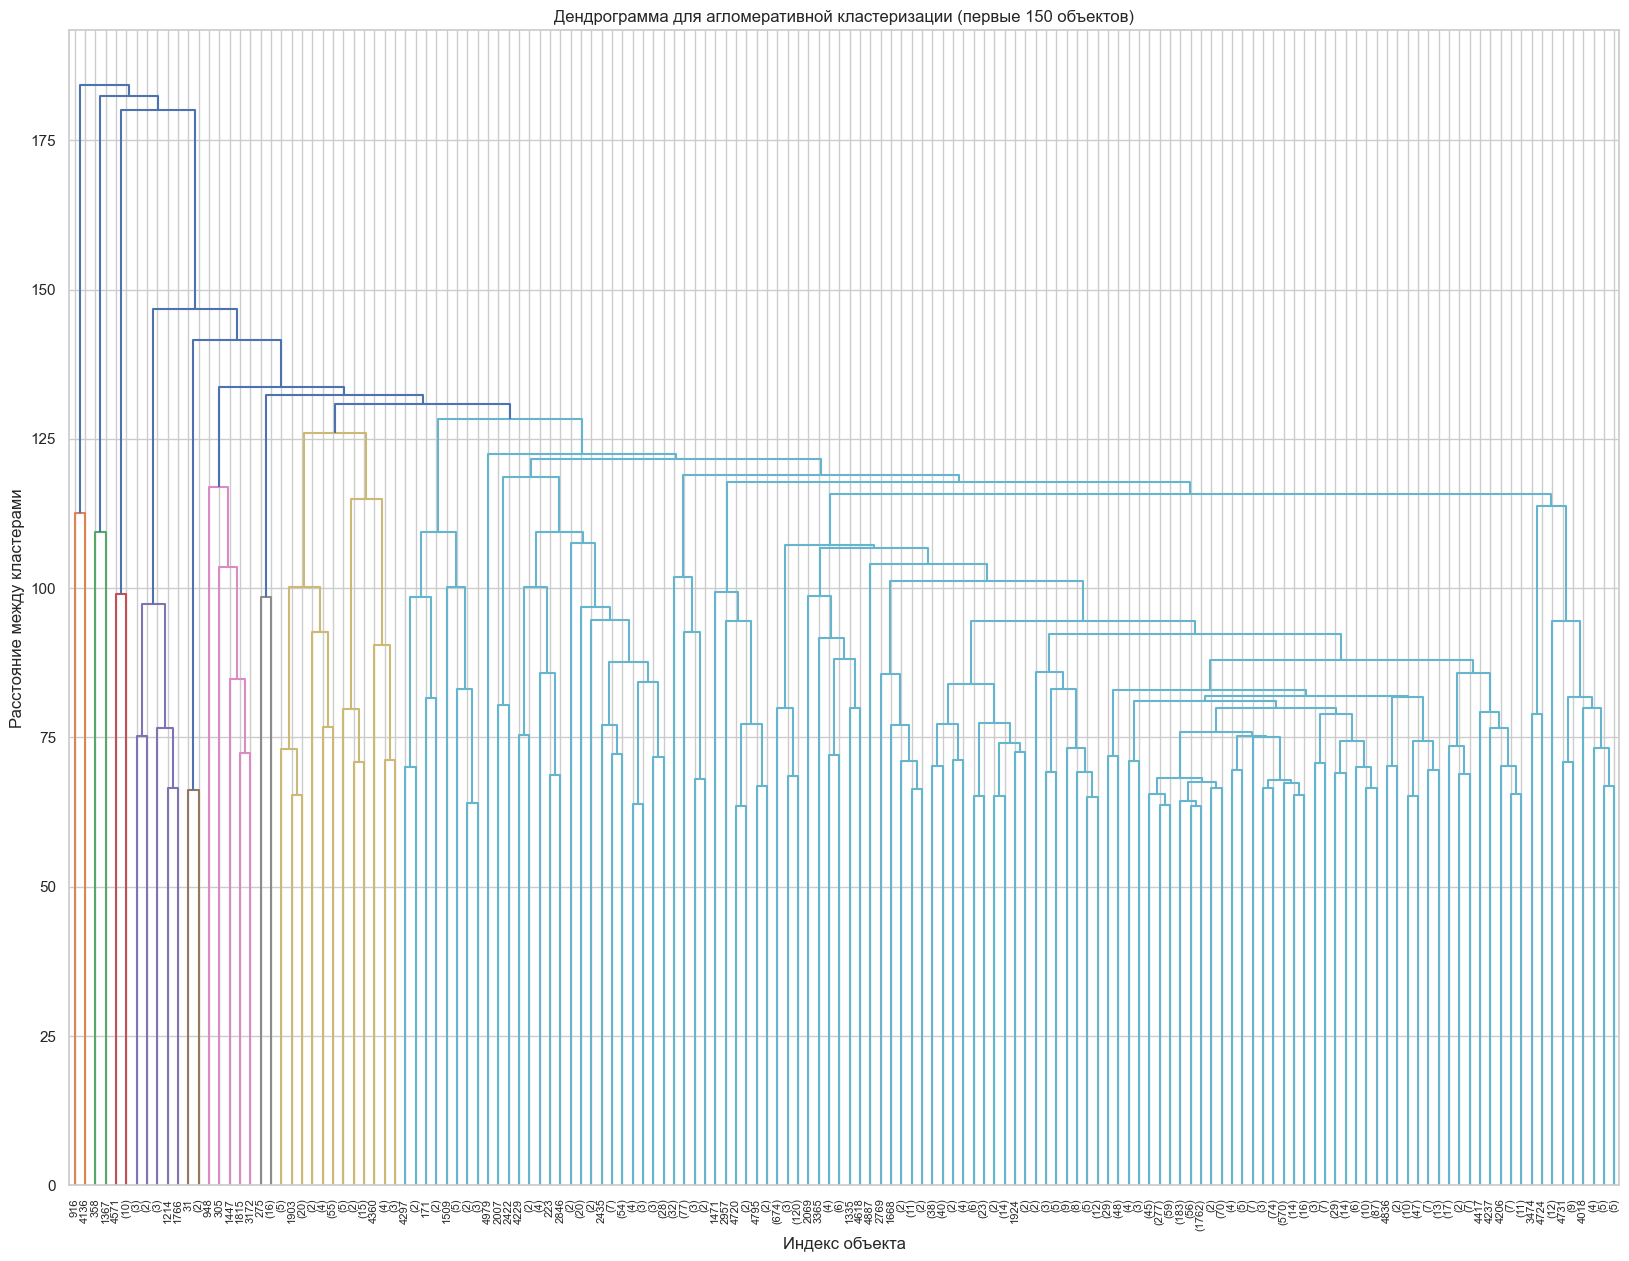

In [28]:
from scipy.cluster.hierarchy import dendrogram, linkage

sample_size_d = 5000 
X_sample_d = X[:sample_size_d]
# Строим матрицу расстояний (linkage matrix)
Z = linkage(X_sample_d, method="average")  # Метод average для минимизации дисперсии

# Строим дендрограмму
plt.figure(figsize=(20, 15))
dendrogram(
    Z, 
    p=150,                  # Показываем 150 листьев
    truncate_mode='lastp',  # Обрезаем до p листьев
    leaf_rotation=90.,
    leaf_font_size=8.,
    show_leaf_counts=True
)
plt.title("Дендрограмма для агломеративной кластеризации (первые 150 объектов)")
plt.xlabel("Индекс объекта")
plt.ylabel("Расстояние между кластерами")
plt.show()

Вывод:
 - По структуре ключевое количество кластеров может быть: 2, 5, 6, 8, 9, 10, 11, 12, 13 - считаю это оптимальным разделением, иначе это будет уже излишне большое разделение.
 - 2 кластера, как ранее предполагалось слишком грубое разделение

In [29]:
# Пробуем разные методы связи
linkage_methods = ['ward', 'complete', 'average', 'single']
sample_size = 10000
X_sample = X_scaled[:sample_size]

print(f"Сравнение методов иерархической кластеризации sample_size = {sample_size}:")
print("=" * 50)

for linkage in linkage_methods:
    for k in [6, 8, 9, 10, 11, 12]:
        hier = AgglomerativeClustering(n_clusters=k, linkage=linkage)
        labels = hier.fit_predict(X_sample)
        score = silhouette_score(X_sample, labels)
        print(f"linkage={linkage}, k={k}: silhouette={score:.4f}")
    print("-" * 50)

Сравнение методов иерархической кластеризации sample_size = 10000:
linkage=ward, k=6: silhouette=0.4895
linkage=ward, k=8: silhouette=0.3413
linkage=ward, k=9: silhouette=0.3503
linkage=ward, k=10: silhouette=0.3536
linkage=ward, k=11: silhouette=0.3561
linkage=ward, k=12: silhouette=0.0729
--------------------------------------------------
linkage=complete, k=6: silhouette=0.4677
linkage=complete, k=8: silhouette=0.4659
linkage=complete, k=9: silhouette=0.4648
linkage=complete, k=10: silhouette=0.4540
linkage=complete, k=11: silhouette=0.4332
linkage=complete, k=12: silhouette=0.4336
--------------------------------------------------
linkage=average, k=6: silhouette=0.6193
linkage=average, k=8: silhouette=0.6047
linkage=average, k=9: silhouette=0.5944
linkage=average, k=10: silhouette=0.5850
linkage=average, k=11: silhouette=0.5798
linkage=average, k=12: silhouette=0.5724
--------------------------------------------------
linkage=single, k=6: silhouette=0.6037
linkage=single, k=8: sil

#### Вывод:
- лучше всего показал себя метод связи linkage=average, совсем немного хуже linkage=single,
- лучшие данные по всем связям при k = 6, 8, 9, 10:
    -  linkage=average, k=6: silhouette=0.6193
    -  linkage=average, k=8: silhouette=0.6047
    -  linkage=average, k=9: silhouette=0.5944
    -  linkage=average, k=10: silhouette=0.5850
    > Начиная с 11 - идет снижение качества
- будем обучать модель на linkage=average, k = 6, 8, 9, 10, проверим больший размер данных sample_size = 30000
- возможно 6 - слишком малое разделение.

In [30]:
# Иерархическая кластеризация (может дать лучшую структуру)
def aggl_cluster(X, name = 'X', n_clusters=2, name_method='Agglomerative_Clustering',\
                 sample_size = 30000, grafh=False):
    #sample_size = sample_size
    X_sample = X[:sample_size]

    print(f'Кластеризаци на наборе данных "{name}":')
    hierarchical = AgglomerativeClustering(n_clusters=n_clusters, linkage="average")
    labels_hier = hierarchical.fit_predict(X_sample)
    score_hier = silhouette_score(X_sample, labels_hier)
    print(f"\n{name_method}: silhouette_score = {score_hier:.4f}")
    if grafh:
        # PCA для визуализации
        pca = PCA(n_components=n_clusters)
        X_pca = pca.fit_transform(X)
        plt.scatter(
            X_pca[:sample_size, 0],
            X_pca[:sample_size, 1],
            c=labels_hier, cmap='viridis',
            alpha=0.6, s=5, edgecolors='none'
            )
        plt.title(f'{name_method}: n_clusters={n_clusters}, score={score_hier:.4f}')    
        plt.xlabel('PCA 1')
        plt.ylabel('PCA 2')      
        plt.show()
    return labels_hier, score_hier
#labels_hier_sc, score_hier_sc = aggl_cluster(X_scaled, 'X_scaled', 2, grafh=True)

Кластеризаци на наборе данных "X_scaled":

Agglomerative_Clustering: silhouette_score = 0.6459


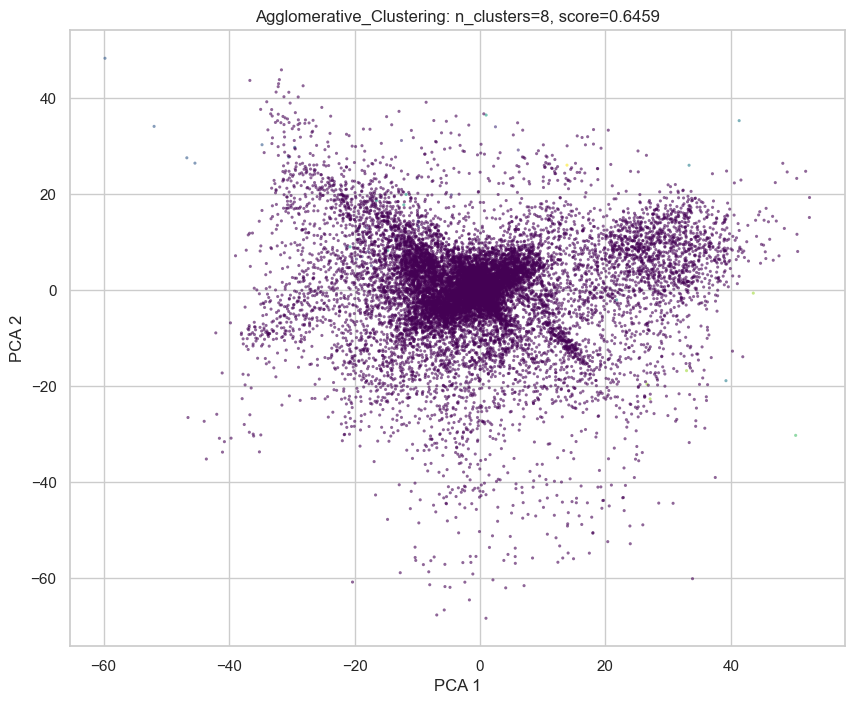

In [31]:
labels_hier_sc, score_hier_sc = aggl_cluster(X_scaled, 'X_scaled', 8, grafh=True)

Кластеризаци на наборе данных "X_scaled":

Agglomerative_Clustering: silhouette_score = 0.6352


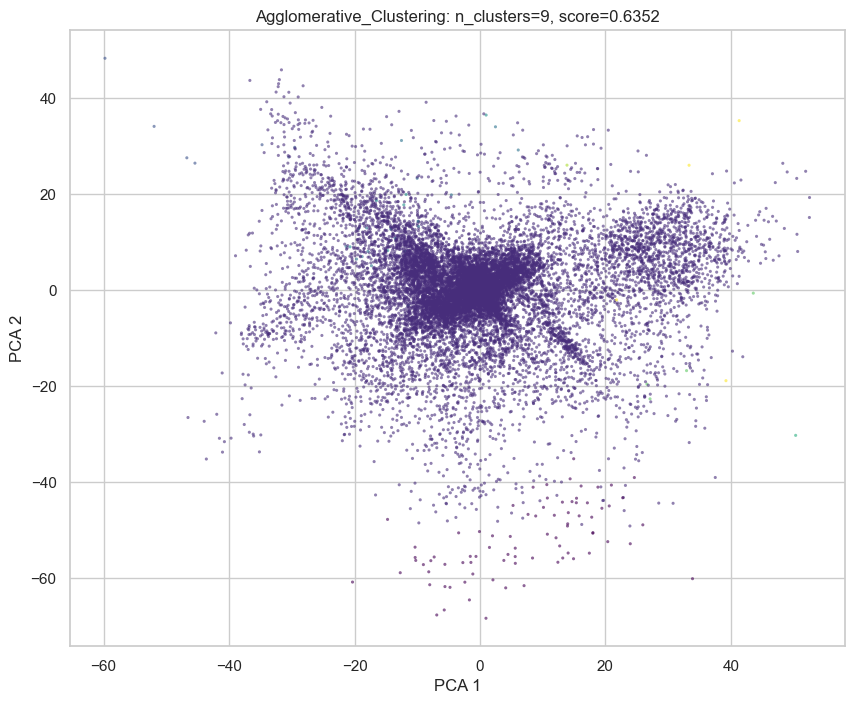

In [32]:
labels_hier_sc, score_hier_sc = aggl_cluster(X_scaled, 'X_scaled', 9, grafh=True)

Кластеризаци на наборе данных "X_scaled":

Agglomerative_Clustering: silhouette_score = 0.6341


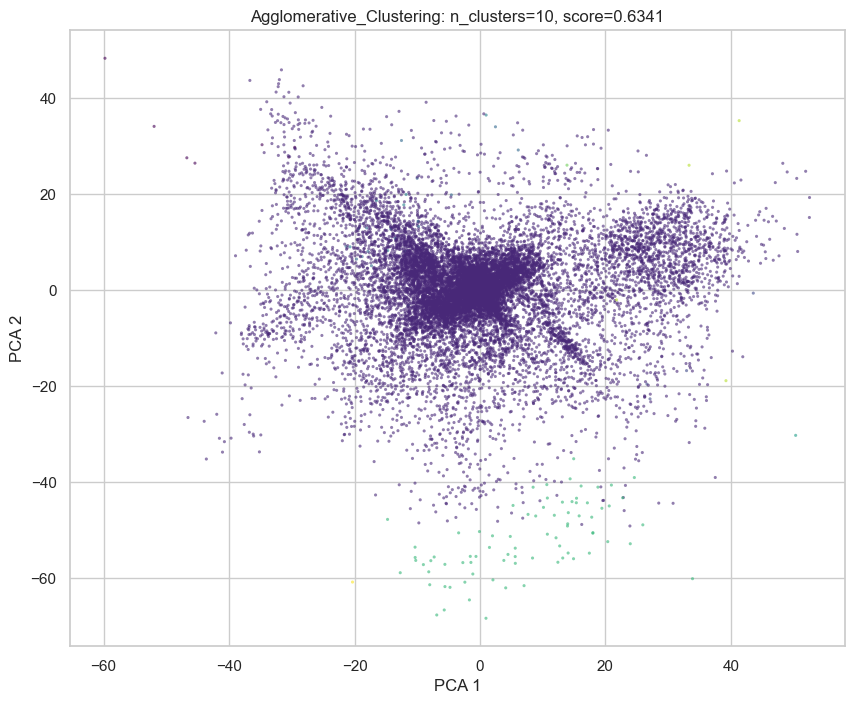

In [33]:
labels_hier_sc, score_hier_sc = aggl_cluster(X_scaled, 'X_scaled', 10, grafh=True)

Вывод:
- На большей выборке score_hier улучшается, возможно наше предположение верно:
- лучший результат k=8, silhouette_score = 0.6459

In [34]:
def grafh_pca(X, name, labels,  n_clusters, sample_size,  name_method):
    # PCA для визуализации
    pca = PCA(n_components=n_clusters)
    X_pca = pca.fit_transform(X)
    plt.scatter(X_pca[:sample_size, 0], X_pca[:sample_size, 1],
                c=labels, cmap='viridis', alpha=0.6, s=5, edgecolors='none'
            )
    plt.title(f'{name_method}: n_clusters = {n_clusters}')
    
    plt.xlabel('PCA 1')
    plt.ylabel('PCA 2')
    
    plt.show()
#grafh_pca(X_scaled, 'X_scaled', labels_hier_sc, 2, sample_size,'Agglomerative Clustering')

#### Вывод:
- лучший результат дал набор данных X_scaled - будем работать с этим набором данных;
- хуже результат показали чистые данные, плохие результаты дал набор данных X_scaled_log
- метод локтя указывает на 2-3 кластера;
- Метод силуэта на части данных X_scaled показал K=2:
    - Silhouette=0.53(MiniBatchKMeans)
    - Иерархическая кластеризация: Silhouette=0.54
- Но дендраграмма показала более сложную структуру данных, поэтому деление на 2 кластера может оказаться грубым, что подтверждают исследования:
  - если смотрим 2 кластера: по структуре - 1 кластер большой и хороший, 0 - кластер очень маленький и плохой.
- посмотрела исходник (в датасете PAMAP2 12 различных активностей - потому, даже если хороший результат на 2 кластеров, будем смотреть и на большее количество), этот момент тоже учтем.
- Проверим ключевые кластеры k=2,5,8,9,10,11,12;
- Проверим разные алгоритмы: KMeans и AgglomerativeClustering, в первую очередь, проверим DBSCAN - посмотрим какое количество кластеров он подберет, HDBSCAN (если необходимо)

## Обучение
- берем для обучения X_scaled
- k=2,5,8,9,10,11,12;

### KMeans и Agglomerative

In [35]:
sample_size = 20000
np.random.seed(42)
sample_indices = np.random.choice(len(X_scaled), sample_size, replace=False)
X_sample = X_scaled[sample_indices]

In [36]:
%%time
# Упрощенная версия для быстрого сравнения
sample_size = 15000
X_sample = X_scaled[np.random.choice(len(X_scaled), sample_size, replace=False)]

models = {
    'KMeans (k=8)': KMeans(n_clusters=8, random_state=42, n_init=10),
    'KMeans (k=10)': KMeans(n_clusters=10, random_state=42, n_init=10),
    'KMeans (k=12)': KMeans(n_clusters=12, random_state=42, n_init=10),
    #'MiniBatchKMeans (k=2)': MiniBatchKMeans(n_clusters=2, random_state=42,\
     #                                        batch_size=5000, n_init=10),
    'MiniBatchKMeans (k=8)': MiniBatchKMeans(n_clusters=8, random_state=142,\
                                             batch_size=5000, n_init=10),
    'MiniBatchKMeans (k=10)': MiniBatchKMeans(n_clusters=10, random_state=142,\
                                             batch_size=5000, n_init=10), #, max_iter=300
    'MiniBatchKMeans (k=11)': MiniBatchKMeans(n_clusters=11, random_state=42,\
                                             batch_size=5000, n_init=10),
    'Agglomerative (k=8)': AgglomerativeClustering(n_clusters=8, linkage='average'),
    'Agglomerative (k=10)': AgglomerativeClustering(n_clusters=10, linkage='average'),
}

print("Сравнение моделей (Silhouette Score):")
print("-" * 40)

for name, model in models.items():
    labels = model.fit_predict(X_sample)
    score = silhouette_score(X_sample, labels)
    n_clusters = len(set(labels))
    print(f"{name:25}:  Score = {score:.4f}, Кластеров: {n_clusters}")

Сравнение моделей (Silhouette Score):
----------------------------------------
KMeans (k=8)             :  Score = 0.4144, Кластеров: 8
KMeans (k=10)            :  Score = 0.3877, Кластеров: 10
KMeans (k=12)            :  Score = 0.1342, Кластеров: 12
MiniBatchKMeans (k=8)    :  Score = 0.4883, Кластеров: 8
MiniBatchKMeans (k=10)   :  Score = 0.0951, Кластеров: 10
MiniBatchKMeans (k=11)   :  Score = 0.2647, Кластеров: 11
Agglomerative (k=8)      :  Score = 0.6444, Кластеров: 8
Agglomerative (k=10)     :  Score = 0.6330, Кластеров: 10
CPU times: user 20.4 s, sys: 14.2 s, total: 34.6 s
Wall time: 14.7 s


##### Вывод:
- K = 5 - лучшее значение, но мало кластеров
- K=10 и K=8 - хороший  результат на KMeans + оптимальное число кластеров:
  - k=10:  Score = 3901
  - k=8: Score = 0.4883 - более стабильный хороший результат
 > В датасете PAMAP2 (откуда взяты данные) реально 12 различных активностей:
   - K=10 приближается к реальному числу активностей!
- Лучшие результаты показывает себя Agglomerative: Score = 0.6444 и Score = 0.6330 - это уже иерархическая модель, посмотрим что подберет DBSCAN.

### DBSCAN

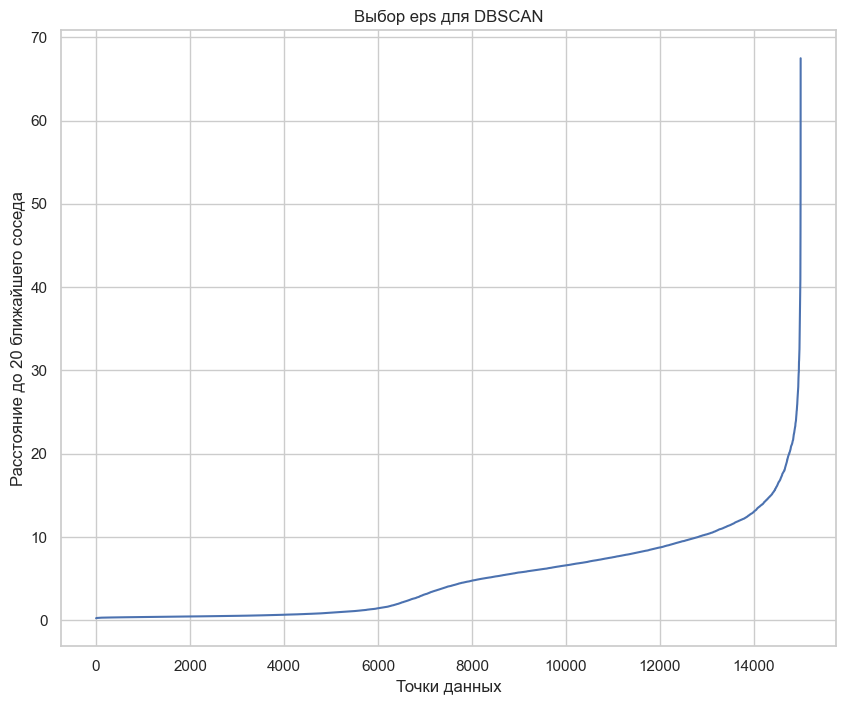

In [37]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

# Ищем расстояния до 20 ближайших соседей
n_neighb=20
nbrs = NearestNeighbors(n_neighbors=n_neighb).fit(X_sample)
distances, _ = nbrs.kneighbors(X_sample)

# Берем 5-е расстояние, сортируем и строим график
distances = np.sort(distances[:, 4])
plt.plot(distances)
plt.xlabel("Точки данных")
plt.ylabel(f"Расстояние до {n_neighb} ближайшего соседа")
plt.title("Выбор eps для DBSCAN")
plt.show()

# На графике ищем "излом" - это и есть оптимальное значение eps.

 Вывод:
 - Метод ближайших соседей показывает eps = (3.0 - 4.5) в области перегиба 

In [38]:
print("Подбор лучших параметров DBSCAN:")
# Тестируем разные комбинации параметров eps в области перегиба (3.0 - 4.5)
param_grid = [
    # eps в области перегиба (3.0 - 4.5)
    (3.0, 50),(3.0, 75),(3.0, 100),(3.0, 150),    
    (3.2, 50),(3.2, 75),(3.2, 100),    
    (3.5, 50),(3.5, 75), (3.5, 100),(3.5, 150),    
    (3.8, 50),(3.8, 75), (3.8, 100),    
    (4.0, 50), (4.0, 75), (4.0, 100),    
    (4.2, 50), (4.2, 75), (4.2, 100),    
    (4.5, 50), (4.5, 75), (4.5, 150),    
    # Контрольные точки (границы)
    (2.5, 100), (5.0, 100),
]
for eps, min_samples in param_grid:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1)
    labels = dbscan.fit_predict(X_sample)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_ratio = sum(labels == -1) / len(labels) * 100
    
    if n_clusters > 0:
        print(f"eps={eps}, min_samples={min_samples}: "
              f"кластеров={n_clusters}, шум={noise_ratio:.1f}%")

Подбор лучших параметров DBSCAN:
eps=3.0, min_samples=50: кластеров=13, шум=55.6%
eps=3.0, min_samples=75: кластеров=11, шум=56.9%
eps=3.0, min_samples=100: кластеров=9, шум=58.3%
eps=3.0, min_samples=150: кластеров=6, шум=62.6%
eps=3.2, min_samples=50: кластеров=11, шум=54.7%
eps=3.2, min_samples=75: кластеров=9, шум=56.2%
eps=3.2, min_samples=100: кластеров=9, шум=57.3%
eps=3.5, min_samples=50: кластеров=8, шум=53.2%
eps=3.5, min_samples=75: кластеров=7, шум=54.1%
eps=3.5, min_samples=100: кластеров=5, шум=55.4%
eps=3.5, min_samples=150: кластеров=5, шум=55.9%
eps=3.8, min_samples=50: кластеров=7, шум=52.0%
eps=3.8, min_samples=75: кластеров=6, шум=52.5%
eps=3.8, min_samples=100: кластеров=5, шум=53.6%
eps=4.0, min_samples=50: кластеров=7, шум=51.4%
eps=4.0, min_samples=75: кластеров=6, шум=52.0%
eps=4.0, min_samples=100: кластеров=5, шум=52.6%
eps=4.2, min_samples=50: кластеров=5, шум=50.8%
eps=4.2, min_samples=75: кластеров=4, шум=51.3%
eps=4.2, min_samples=100: кластеров=4, шум=52

In [39]:
# Выбираем оптимальные параметры (например, eps=3.5, min_samples=50)
#k=10 # шум=54.2%
#optimal_eps = 3.2, optimal_min_samples = 50
#k=8 # шум=53.2%
optimal_eps=3.5 
optimal_min_samples=50

dbscan_opt = DBSCAN(eps=optimal_eps, min_samples=optimal_min_samples, n_jobs=-1)
labels_opt = dbscan_opt.fit_predict(X_sample)

n_clusters = len(set(labels_opt)) - (1 if -1 in labels_opt else 0)
noise_count = sum(labels_opt == -1)
noise_ratio = noise_count / len(labels_opt) * 100

print(f"\nОптимальные параметры: eps={optimal_eps}, min_samples={optimal_min_samples}")
print(f"Найдено кластеров: {n_clusters}")
print(f"Шум: {noise_count} ({noise_ratio:.1f}%)")

# Статистика по кластерам
print("\nСтатистика кластеров:")
for label in sorted(set(labels_opt)):
    if label == -1:
        print(f"  Шум: {sum(labels_opt == label)} точек")
    else:
        print(f"  Кластер {label+1}: {sum(labels_opt == label)} точек")


Оптимальные параметры: eps=3.5, min_samples=50
Найдено кластеров: 8
Шум: 7981 (53.2%)

Статистика кластеров:
  Шум: 7981 точек
  Кластер 1: 2035 точек
  Кластер 2: 4043 точек
  Кластер 3: 196 точек
  Кластер 4: 215 точек
  Кластер 5: 76 точек
  Кластер 6: 309 точек
  Кластер 7: 60 точек
  Кластер 8: 85 точек


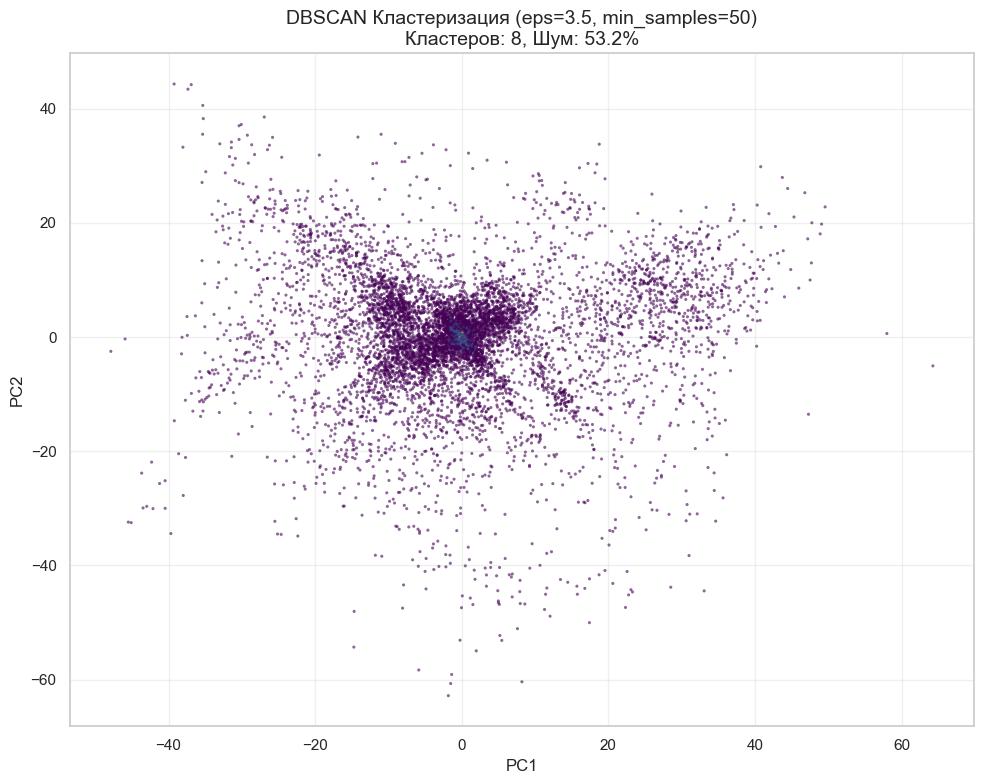

In [40]:
# PCA для визуализации
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sample)

#plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                      cmap='viridis', 
                      c=labels_opt, alpha=0.6, s=5, edgecolors='none')
plt.title(f'DBSCAN Кластеризация (eps={optimal_eps}, min_samples={optimal_min_samples})\n'
          f'Кластеров: {n_clusters}, Шум: {noise_ratio:.1f}%', fontsize=14)
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### HDBSCAN 

In [ ]:
# print("\nАльтернатива: HDBSCAN (может дать лучшие результаты)")

# import hdbscan
# #X_sample = X_scaled[sample_indices]
# # HDBSCAN автоматически определяет количество кластеров
# hdb = hdbscan.HDBSCAN(min_cluster_size=500, min_samples=50, prediction_data=True)
# labels_hdb = hdb.fit_predict(X_sample)

# n_clusters_hdb = len(set(labels_hdb)) - (1 if -1 in labels_hdb else 0)
# noise_ratio_hdb = sum(labels_hdb == -1) / len(labels_hdb) * 100

# print(f"HDBSCAN результаты:")
# print(f"  Кластеров: {n_clusters_hdb}")
# print(f"  Шум: {sum(labels_hdb == -1):,} ({noise_ratio_hdb:.1f}%)")

#### Вывод:
Для DBSCAN на данных 20000:
- Лучшие параметры: eps = 3.5, min_samples = 50
   - Дает ровно 8 кластеров
   - Шум 53.2%
- Проблема DBSCAN, HDBSCAN  - не подходят для данных:
   - Шум > 50% - неприемлемо (более 50% данных остаются неклассифицированными)
   - Нет четкой кластерной структуры (точки распределены непрерывно)
   - Разная плотность активностей
- возвращаемся к KMeans - быстрый, легко интерпретируемый метод

In [41]:
comparison = {
    'Метод': [
                'Agglomerative (average, k=8)', 
                'Agglomerative (average, k=10)',
                'MiniBatchKMeans (k=8)',
                'KMeans (k=10)',
                'DBSCAN (eps=3.2, min_samples=50)'
            ],
    'Кластеров': [8, 10, 8, 10, 8],
    'Шум %': [0, 0, 0, 0, 54.2],
    'Силуэт': [0.6444, 0.6330, 0.4883, 0.3820, 'N/A'],
    'Пригодность': ['Отлично', 'Отлично', 'Очень хорошо', 'Хорошо', '50% потерь']
}

df_compare = pd.DataFrame(comparison)
print(df_compare.to_string(index=False))

                           Метод  Кластеров  Шум %  Силуэт  Пригодность
    Agglomerative (average, k=8)          8    0.0  0.6444      Отлично
   Agglomerative (average, k=10)         10    0.0   0.633      Отлично
           MiniBatchKMeans (k=8)          8    0.0  0.4883 Очень хорошо
                   KMeans (k=10)         10    0.0   0.382       Хорошо
DBSCAN (eps=3.2, min_samples=50)          8   54.2     N/A   50% потерь


### Вывод:

- K=10 - лучший результат на KMeans:
  - На финалке проверим:
    > MiniBatchKMeans (k=8)': MiniBatchKMeans(n_clusters=10, random_state=142,batch_size=5000, n_init=10)
- также смотрим Agglomerative (k=10), но тут вопрос в ресурсах - проверим.
  - Для финального решения:
   >  берем AgglomerativeClustering (linkage='average', n_clusters=10)\
      Это даст 100% точек в кластерах и силуэт 0.5850
- DBSCAN при eps = 3.5, min_samples = 50 стабильно определяет k=8 и показала низкий уровень шума:
- но DBSCAN  - не подходит для наших данных.
   - Шум > 50% - неприемлемо (более 50% данных остаются неклассифицированными)
   - Нет четкой кластерной структуры
- все 3 метода хорошо повели себя при k=8 и k=10, потому будем тестировать на 10 кластерах.

## Проверка лучшей модели, подготовка к сабмиту

### kmeans

In [42]:
%%time
print(" Кластеризация:")

kmeans_final = MiniBatchKMeans(n_clusters=8, random_state=142, batch_size=5000, n_init=20, max_iter=300)
clusters = kmeans_final.fit_predict(X_scaled)
print(f"   Кластеризация завершена. Кластеров: {len(set(clusters))}")


 Кластеризация:
   Кластеризация завершена. Кластеров: 8
CPU times: user 871 ms, sys: 1.59 s, total: 2.46 s
Wall time: 240 ms


In [ ]:
# %%time
# #не подходит - на батчах лучше обучать
# kmeans_final = KMeans( n_clusters=8, random_state=142, 
#                         n_init=20,          # критический параметр
#                         max_iter=200,        # Уменьшаю (100-200 оптимально)
#                         algorithm='lloyd'    # Классический алгоритм (более стабильный)
#                     )
# clusters = kmeans_final.fit_predict(X_scaled)

In [43]:
#clusters = clusters_kmeans.copy()
# Добавляем кластеры в DataFrame
df_filled['cluster'] = clusters
df_filled.sample(5)

handTemperature  handAcc16_1  handAcc16_2  handAcc16_3  \
subject_id timestamp                                                           
6          3163.80            28.6875    21.560300    -4.844170      1.91888   
           150.25             33.3125     4.996850    -0.447042      8.08334   
5          3105.25            34.4375    -3.425420    -1.764920      1.84213   
           2343.87            34.5000    -5.368490     4.665960      2.21469   
           536.29             34.9375    -0.088837     6.602720      7.02119   

                      handAcc6_1  handAcc6_2  handAcc6_3  handGyro1  \
subject_id timestamp                                                  
6          3163.80     20.000500   -3.374910   -0.351511  -2.401120   
           150.25       5.190070   -0.662262    8.370840   0.008511   
5          3105.25     -5.870940    4.053090    7.405370  -0.637381   
           2343.87     -5.075560    4.797990    2.615980   1.351160   
           536.29       0.042135    6.607840    7.227620   0.004747   

                      handGyro2  handGyro3  ...  ankleGyro2  ankleGyro3  \
subject_id timestamp                        ...                           
6          3163.80     0.139282  -0.095980  ...   -0.619780    0.975321   
           150.25      0.043607  -0.013284  ...   -0.013640    0.008232   
5          3105.25     0.063683   0.305647  ...    0.200702    0.356535   
           2343.87    -0.094715  -1.114900  ...    1.129870    6.024170   
           536.29      0.021707  -0.016547  ...   -0.017502   -0.027237   

                      ankleMagne1  ankleMagne2  ankleMagne3  \
subject_id timestamp                                          
6          3163.80       -41.9872     16.80340     19.39560   
           150.25        -16.7072     27.31440     -5.20645   
5          3105.25       -45.5719     15.26240      3.78324   
           2343.87       -33.6197    -35.14730      7.42957   
           536.29        -35.7228      2.74131     28.22750   

                      ankleOrientation1  ankleOrientation2  ankleOrientation3  \
subject_id timestamp                                                            
6          3163.80             0.305498           0.621345           0.458089   
           150.25              0.181416           0.248421           0.758588   
5          3105.25             0.507964           0.449568           0.622990   
           2343.87             0.507542          -0.599054           0.521710   
           536.29              0.044193          -0.754063           0.295782   

                      ankleOrientation4  cluster  
subject_id timestamp                              
6          3163.80             0.557455        2  
           150.25             -0.574386        0  
5          3105.25             0.389543        2  
           2343.87            -0.333697        4  
           536.29             -0.584765        2  

[5 rows x 52 columns]

Визуализация:


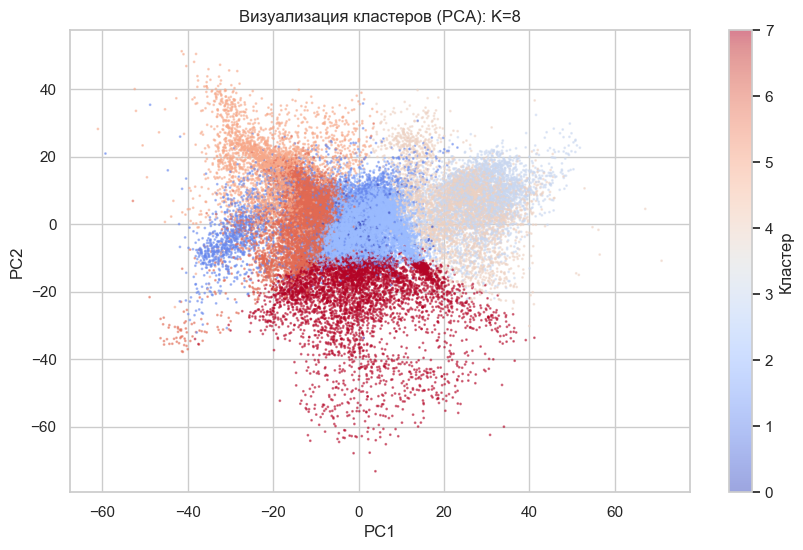

In [44]:
print("Визуализация:")
# Берем выборку для визуализации
sample_size = min(100000, len(X_scaled))
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), sample_size, replace=False)

pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled[sample_idx])

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                       c=clusters[sample_idx], cmap='coolwarm', alpha=0.5, s=1)
plt.colorbar(scatter, label='Кластер')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'Визуализация кластеров (PCA): K={len(set(clusters))}')
plt.show()

# print("Анализ результатов:")
# cluster_sizes = df_filled['cluster'].value_counts().sort_index()
# print(f"   Распределение по кластерам:")
# for i in range(9):
#     print(f"     Кластер {i}: {cluster_sizes[i]:,} ({cluster_sizes[i]/len(df_filled)*100:.1f}%)")

# # Проверка независимости от субъектов
# print(f"\n   Распределение по субъектам (%):")
# cross_tab = pd.crosstab(df_filled.index.get_level_values('subject_id'), 
#                          df_filled['cluster'], normalize='index')
# print(cross_tab.round(3))

### Подготовка файла для сабмита

In [45]:
print(f"\nФинальная кластеризация с K={len(set(clusters))}")
submission = pd.DataFrame({
    'Index': np.arange(len(df_filled)),
    'activityID': clusters + 1
})

submission.to_csv('submission_kb8.csv', index=False)
print("\nСабмит создан: submission_kb8.csv")
print(submission['activityID'].value_counts().sort_index())


Финальная кластеризация с K=8

Сабмит создан: submission_kb8.csv
activityID
1     90775
2     19176
3    300353
4     16924
5     20492
6     16253
7     45121
8     25507
Name: count, dtype: int64


In [46]:
print('таблица загрузок сабмитов с k=2,8,10,11')
data = {
    'K': [2, 8, 10, 11],
    'Silhouette': [0.4322, 0.4883, 0.1000, 0.2647],
    'Kaggle_Score': [0.18076, 0.37901, 0.35849, 0.12310],
    'Оценка': ['Слишком грубое разделение', \
               'Более стабильный результат', \
               'Соответствует реальности, но менее стабильный результат',\
               'Слишком много кластеров (переизмельчение)']
}
table = pd.DataFrame(data)
display(table)

# Сохраняем
#df.to_csv('my_results.csv', index=False)
#print("\nТаблица сохранена в my_results.csv")

таблица загрузок сабмитов с k=2,8,10,11


,K,Silhouette,Kaggle_Score,Оценка
0,2,0.4322,0.18076,Слишком грубое разделение
1,8,0.4883,0.37901,Более стабильный результат
2,10,0.1000,0.35849,"Соответствует реальности, но менее стабильный ..."
3,11,0.2647,0.12310,Слишком много кластеров (переизмельчение)


#### Сохраняем

In [49]:
submission.to_csv('submission.csv', index=False)
print(f"   Формат: {submission.shape[0]} строк, колонки: {list(submission.columns)}")
print(f"   Кластеры в сабмите: {sorted(submission['activityID'].unique())}")
print("Файл для отправки: submission.csv")

   Формат: 534601 строк, колонки: ['Index', 'activityID']
   Кластеры в сабмите: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8)]
Файл для отправки: submission.csv


### AgglomerativeClustering

### Вывод:
- Очень низкое значение на тесте AgglomerativeClustering: 0.18063
    - получили один гигантский кластер (99.8% данных) и 9 крошечных.
      > очевидно, что на такой выборке алгоритм AgglomerativeClustering не смог обобщить структуру, больше выборку ресурс не позволяет сделать
- Хорошо в итоге показала себя модель Kmeans с k = 8 и k =10, особенно выигрывает по времени 1 мин против 10 мин.
- потому приходим к итоговому **Kmeans: 0.37901, k = 8**